## 1. Initial Data Exploration

In [1]:
## Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import nltk 
import re 
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras import layers
import tensorflow as tf
from tensorflow.keras import callbacks
import joblib
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertModel
from tqdm import tqdm
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
import random

c:\Users\EASYPC\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



In this project, we focus on predicting reader satisfaction ratings based on textual book reviews. The dataset consists of reviews, each accompanied by a rating on a scale from 1 (poor) to 5 (excellent).

Two datasets are provided:  
- A **training set** containing reviews with corresponding ratings.  
- A **test set** containing reviews without ratings, for which the goal is to predict the ratings accurately.

The objective is to develop a predictive model that estimates the rating given the review text alone, maximizing prediction accuracy on unseen data.




The model performance is evaluated using the **Mean Absolute Error (MAE)**, which quantifies the average absolute difference between the true ratings and the predicted ratings.

The formula for MAE is:

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

where:  
- $n$ is the number of samples,  
- $y_i$ is the true rating for sample $i$,  
- $\hat{y}_i$ is the predicted rating for sample $i$.


### 1.1 Loading Data sets

In [2]:
# loading reviews dataset
data= pd.read_csv('ATML2025_book_reviews_train.csv')
data.head()

,id,Title,Price,profileName,helpfulness,rating,time,summary,text
0,0,Monster Mama,NaN,NaN,1/4,3,2002-02-09,mixed feelings,"The illustrations caught my eye, but the pictu..."
1,1,The Five Love Languages: The Secret to Love th...,19.25,rw,0/0,5,2012-07-27,For EVERY relationship - not just marriage.,I had heard of this book forever. I finally ch...
2,2,Red Rabbit,NaN,S. Hall,0/0,1,2002-09-03,Waving the White Flag,"Like most of the other reviewers here, I used ..."
3,3,Tale of Mrs. William Heelis - Beatrix Potter,NaN,J. Underwood,3/3,4,2009-07-17,More Mrs. Heelis than Beatrix Potter,This is more a Heelis family history than a bi...
4,4,A Moveable Feast (Bantam Book),NaN,"Deltenney ""Deltenney""",0/0,4,2012-09-03,Edited Version of A Moveable Feast,I read A Moveable Feast after reading the life...


In [3]:
# loading books dataset
books=pd.read_csv('ATML2025_books.csv')
books.head()


,Title,description,authors,publisher,publishedDate,categories
0,Dr. Seuss: American Icon,Philip Nel takes a fascinating look into the k...,['Philip Nel'],A&C Black,2005-01-01,['Biography & Autobiography']
1,Wonderful Worship in Smaller Churches,This resource includes twelve principles in un...,['David R. Ray'],NaN,2000,['Religion']
2,Whispers of the Wicked Saints,Julia Thomas finds her life spinning out of co...,['Veronica Haddon'],iUniverse,2005-02,['Fiction']
3,The Church of Christ: A Biblical Ecclesiology ...,In The Church of Christ: A Biblical Ecclesiolo...,['Everett Ferguson'],Wm. B. Eerdmans Publishing,1996,['Religion']
4,The Overbury affair (Avon),NaN,['Miriam Allen De Ford'],NaN,1960,NaN


We merged the reviews, readers and books datasets to create a unified dataset containing all necessary information for our analysis. The resulting dataset contains approximately 357,000 reviews and 14 columns of information, including metadata about the reviews, books, and users.

In [4]:
df= pd.merge(data, books, on='Title', how='left')
df.shape

(357000, 14)

### 1.2 Checking Missing values

In [5]:
# checking for missing values
missing_percentage = df.isnull().mean() * 100
print(missing_percentage.sort_values(ascending=False))

Price            82.001120
publisher        25.633053
description      21.173669
profileName      18.856303
categories       17.207563
authors          13.266947
publishedDate    11.605882
id                0.000000
Title             0.000000
helpfulness       0.000000
rating            0.000000
time              0.000000
summary           0.000000
text              0.000000
dtype: float64


- The price column has approximately 82% missing values, making it unreliable for analysis or modeling. Due to this high level of missingness, we decided to exclude this column from the study, as its contribution would be minimal and potentially misleading.

- Other columns, such as authors or categories, have missing values to a lesser extent. While these columns are not directly used in our initial modeling pipeline, they could be valuable in future analysis or exploratory tasks. To preserve the records and maintain consistency, we suggest imputing missing values in these fields with a placeholder such as "Unknown" if needed later in the project.

### 1.3 Target Distribution

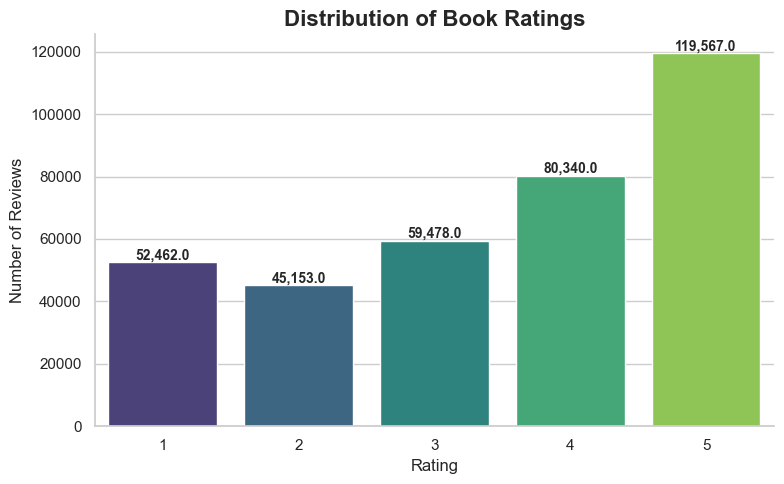

In [6]:

# Set a clean style
sns.set(style="whitegrid")

# Define a custom color palette (optional)
custom_palette = sns.color_palette("viridis", n_colors=len(df['rating'].unique()))

# Create the plot
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    x='rating',
    hue='rating',
    data=df,
    palette=custom_palette,
    order=sorted(df['rating'].unique()),
    legend=False
)

# Annotate bars with counts
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,}', (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Titles and labels
plt.title('Distribution of Book Ratings', fontsize=16, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

# Remove top and right spines
sns.despine()

# Tight layout
plt.tight_layout()
plt.show()


An initial analysis of the rating distribution reveals that most readers tend to leave favorable reviews, with ratings of 4 and 5 being the most common. This results in a right-skewed distribution of the target labels. We should take this imbalance into consideration in the subsequent tasks, as it may bias models toward predicting higher ratings. Despite being fewer in number, low-rated reviews (1 and 2 stars) carry critical feedback about what readers dislike. Analyzing these negative reviews is therefore particularly important, as they can provide valuable insights for improving book selection and guiding future recommendations.



### 1.4 Data Splitting and Preprocessing

While the dataset contains multiple informative columns that may contribute to rating prediction, a full exploratory analysis would be required to assess their predictive value. In this project, we focused on the text of the review and its corresponding summary as the main features, assuming they carry the most relevant information for predicting the rating.

To enrich the textual input for modeling and analysis, we combined the summary and review columns into a single text column. This allows us to capture both the short headline (summary) and the detailed content of the review in one place, which may help models and analyses better understand user sentiment and preferences. There are no missing values in the summary or text columns, but to avoid issues later (e.g., on new data), we still apply `fillna('')` as a precaution.

In [ ]:
# combining summary and text columns into a single review column
df['review']=df['summary'].fillna('') + ' ' + df['text'].fillna('')
# drop duplicates : there are arround 18k duplicates 
df.drop_duplicates(subset=['review'], inplace=True)

In [8]:
# splitting the dataset into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(df[['review']], df['rating'], test_size=0.2, random_state=42)

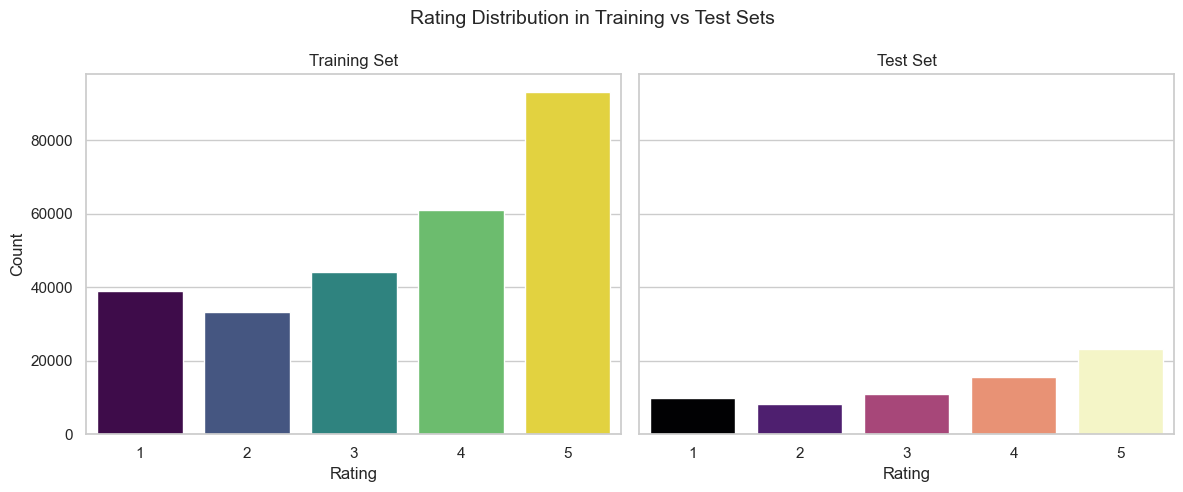

In [9]:
# checking distribution of ratings in training and test sets
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot training set
sns.countplot(x=y_train,hue=y_train ,palette='viridis', ax=axes[0],legend=False)
axes[0].set_title('Training Set')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Plot test set
sns.countplot(x=y_test, hue=y_test ,palette='magma', ax=axes[1],legend=False)
axes[1].set_title('Test Set')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('')

plt.suptitle('Rating Distribution in Training vs Test Sets', fontsize=14)
plt.tight_layout()
plt.show()


The distributions of `y_trai`n and `y_test` closely mirror the distribution of the original ratings. This indicates that the data split preserved the class proportions effectively, ensuring that both the training and testing sets are representative of the overall dataset

To clean the review text before feeding it into the model, we applied a simple preprocessing function: this function removes URLs (e.g., starting with http or www) which are not useful for understanding sentiment. It also normalizes whitespace to avoid unnecessary tokens and strips extra spaces at the beginning and end of the text.

In [10]:
#  Preprocessing 
def preprocess(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [11]:
# comparing original and preprocessed reviews
indices = [192536, 319964]
pd.set_option('display.max_colwidth', None)

# Build a comparison DataFrame
comparison_df = pd.DataFrame({
    "Index": indices,
    "Original Review": [X_train['review'].loc[i] for i in indices],
    "Preprocessed Review": [preprocess(X_train['review'].loc[i]) for i in indices]
})

# Display
comparison_df

,Index,Original Review,Preprocessed Review
0,192536,"Questionable Mr. Ventimiglia started Catholic, spent a few years dabbling in other religions and when people in those other religions disagreed with him he returned to Catholicism. Read his own opinions on his personal web page at:http://www.geocities.com/mark71565/For a book on Wicca I would look for something written by someone serious about it and not some charismatic dabbler who was taking a few years off from Catholicism. For a Prayer Book, pick up Ceisiwr Serith's while it's still in print.","Questionable Mr. Ventimiglia started Catholic, spent a few years dabbling in other religions and when people in those other religions disagreed with him he returned to Catholicism. Read his own opinions on his personal web page at: a book on Wicca I would look for something written by someone serious about it and not some charismatic dabbler who was taking a few years off from Catholicism. For a Prayer Book, pick up Ceisiwr Serith's while it's still in print."
1,319964,"Grindin fo' keeps If you enjoyed ""Little Ghetto Girl"" you will love ""Grindin'"" Danielle shows her reading audience two different kind's of hustle, rather your in the street or all glamed up on the stage you will find yourself on the grind 24/7 and it ain't as easy as it seems. In order to stay on top you have to stay focused. Danielle Santiago has done it once again with a five star soon to be best seller for 2006. www.coast2coastreaders.com","Grindin fo' keeps If you enjoyed ""Little Ghetto Girl"" you will love ""Grindin'"" Danielle shows her reading audience two different kind's of hustle, rather your in the street or all glamed up on the stage you will find yourself on the grind 24/7 and it ain't as easy as it seems. In order to stay on top you have to stay focused. Danielle Santiago has done it once again with a five star soon to be best seller for 2006."


In [12]:
# preprocess the reviews
X_train['review'] = X_train['review'].apply(preprocess)
X_test['review'] = X_test['review'].apply(preprocess)

## 2. Model Training & Evaluation

### 2.1 Word Embedding and Logistic Regression


Bag-of-Words (BoW) is a simple and widely used text embedding technique.
In BoW, each word is represented as a one-hot encoded numeric vector of word counts.
The length of these vectors equals the size of the (possibly reduced) vocabulary
from the training corpus.

In the resulting sparse matrix:
- Each column corresponds to a unique word (feature) in the vocabulary.
- Each row corresponds to a different document (observation).
- Each matrix entry indicates how many times the word (column) appears in the document (row).

This representation transforms text data into numerical form suitable for machine learning models.

We implemented a logistic regression model as a simple baseline. Logistic regression is a linear model commonly used for classification tasks. It estimates the probability of each possible class and predicts the most likely one. In this case, the model was used to predict discrete rating values from text reviews. While it does not account for the ordinal nature of ratings, it provides a solid reference point for comparing more advanced models such as LSTM and DistilBERT.


In [13]:
def train_and_evaluate_classifier(vectorizer, X_train, X_test, y_train, y_test):
    pipeline = Pipeline([
        ('vect', vectorizer),
        ('clf', LogisticRegression(max_iter=5000, random_state=42))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    return pipeline,mae,y_pred


In [14]:
start = time.time()
pipeline_bow,mae_count,p = train_and_evaluate_classifier(CountVectorizer(lowercase=True), X_train['review'], X_test['review'], y_train, y_test)
end = time.time()
  
#  Save the pipeline after training
#joblib.dump(pipeline_bow, 'trained_bow_pipeline.joblib')

# Load the saved trained pipeline
#pipeline_bow = joblib.load('trained_bow_pipeline.joblib')

# time 3382.69 seconds for counter vectorizer
#time_bow = 3382.69/60
time_bow = (end - start) / 60  # Convert to minutes
print(f"Training and evaluation time of BOW vectorizer: {time_bow:.2f} minutes")


c:\Users\EASYPC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training and evaluation time of BOW vectorizer: 43.74 minutes


In [ ]:
joblib.dump(pipeline_bow, 'trained_bow_pipeline.joblib')


In [15]:
# Predicting on the test set
y_pred_bow = pipeline_bow.predict(X_test['review'])
# Calculating Mean Absolute Error
mae_count = mean_absolute_error(y_test, y_pred_bow)
print(f"Mean Absolute Error (Count Vectorizer): {mae_count:.4f}")

#matrix shape
X_vec = pipeline_bow.named_steps['vect'].transform(X_train['review'])
print(f"The matrix shape of BOW:{X_vec.shape}")

Mean Absolute Error (Count Vectorizer): 0.6548
The matrix shape of BOW:(270454, 281859)


Next, we try TF-IDF (Term Frequency-Inverse Document Frequency), 
which builds upon the BoW representation by weighting the word counts 
according to their importance.

TF-IDF transforms the raw word counts into a score that reflects:
- Term Frequency (TF): how often a word appears in a document, and
- Inverse Document Frequency (IDF): how rare the word is across all documents.


The formula for **TF-IDF** of term *t* in document *d* is:

$$
\mathrm{TF\text{-}IDF}(t, d) = \mathrm{TF}(t, d) \times \mathrm{IDF}(t)
$$

where

$$
\mathrm{TF}(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in document } d}
$$

and

$$
\mathrm{IDF}(t) = \log \left( \frac{|D|}{1 + \mathrm{DF}(t)} \right)
$$

with:  
- $|D|$ = total number of documents  
- $\mathrm{DF}(t)$ = number of documents containing term $t$


In [16]:
start = time.time()
pipeline_tf,mae_tfidf,p1 = train_and_evaluate_classifier(TfidfVectorizer(lowercase=True), X_train['review'], X_test['review'], y_train, y_test)
end = time.time()

# save the pipeline after training
joblib.dump(pipeline_tf, 'trained_pipeline_tfidf.joblib')

# Load the  saved trained pipeline
#pipeline_tf = joblib.load('trained_pipeline_tfidf.joblib')

#time_tfidf = 168.57/60
time_tfidf = (end - start) / 60  # Convert to minutes
print(f"Training and evaluation time of tf-idf vectorizer: {time_tfidf:.2f} minutes")

Training and evaluation time of tf-idf vectorizer: 4.10 minutes


In [17]:
# Predicting on the test set
y_pred_tf = pipeline_tf.predict(X_test['review'])
# Calculating Mean Absolute Error
mae_tfidf = mean_absolute_error(y_test, y_pred_tf)
print(f"Mean Absolute Error (Tfidf Vectorizer): {mae_tfidf:.4f}")

# matrix shape
X_vec_tf=pipeline_tf.named_steps['vect'].transform(X_train['review'])
print(f"The matrix shape of TF-IDF:{X_vec_tf.shape}")

Mean Absolute Error (Tfidf Vectorizer): 0.5952
The matrix shape of TF-IDF:(270454, 281859)


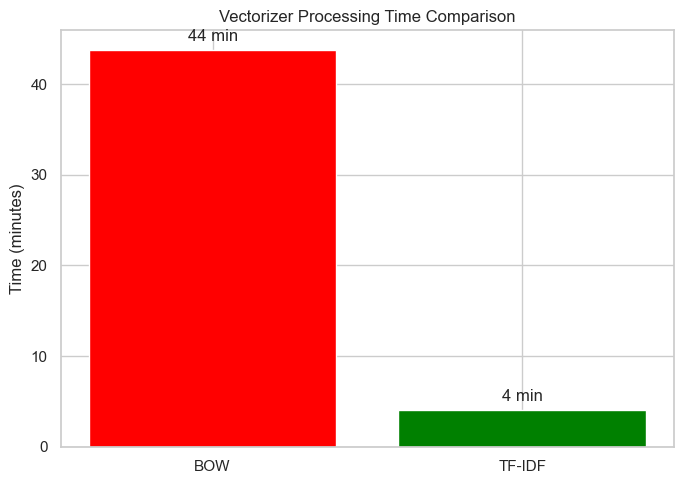

In [18]:

# Names of the two vectorizer configurations
vectorizers = ['BOW', 'TF-IDF']
times = [time_bow, time_tfidf]  # Time in minutes

# Create bar chart
plt.figure(figsize=(7, 5))
bars = plt.bar(vectorizers, times, color=['red', 'green'])
plt.ylabel('Time (minutes)')
plt.title('Vectorizer Processing Time Comparison')

# Add time values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.0f} min', ha='center')

plt.tight_layout()
plt.show()


Using the same Logistic Regression model, BoW took 44 minutes to train, whereas TF-IDF completed in only 4 minutes. This highlights the efficiency gain of TF-IDF in both training time and sparsity handling.

 **Comparison performance of Bag of Words and TF-IDF**

By comparing the two embedding techniques — **Bag of Words (BoW)** and **TF-IDF** — using the same model, we observed that the Mean Absolute Error (MAE) decreased from 0.65 (BoW) to 0.59 (TF-IDF).

This improvement can be explained by the way each method treats word importance:

- **BoW** treats all words equally, simply counting how often each word appears in a document. This means that very common words like *"the"*, *"is"*, or *"and"* may be assigned similar importance to more meaningful terms.

- In contrast, **TF-IDF** not only considers how frequently a word appears in a document (*term frequency*), but also how rare or unique it is across the entire corpus (*inverse document frequency*). This allows TF-IDF to downweight common words that are less informative and emphasize rare, context-specific terms that better characterize the content.


**Hypeparameter tunning** 

To optimize the performance of our text classification model, we conducted a comprehensive hyperparameter tuning process using `GridSearchCV`. The objective was to identify the combination of preprocessing and model parameters that minimizes the mean absolute error (MAE) on the validation set.

**Parameters Tuned**

**1. TF-IDF Parameters:**

* `min_df`: Controls the minimum document frequency a term must have to be considered. Lower values allow rare terms, which may capture subtle patterns but also introduce noise.
* `max_df`: Excludes terms that appear in too many documents. High-frequency terms often carry little discriminatory power.
* `ngram_range`: Defines the range of n-values for different n-grams to be extracted. Including bigrams or trigrams (e.g., (1,2)) helps capture word sequences and context, improving the model's understanding of short phrases beyond individual words.

 **2. Logistic Regression Parameters:**

* `max_iter`: Maximum number of iterations allowed for solver convergence. A higher value ensures the solver has enough iterations to converge.
* `solver`: Algorithm used for optimization. `lbfgs` :Stochastic Gradient Descent variant, `saga`: Quasi-Newton optimizer.


A grid search was conducted over a carefully selected range of values for each parameter. Cross-validation (`cv=5`) was used to ensure robust performance estimation, and the evaluation metric was the negative mean absolute error, reflecting our goal of minimizing prediction error across ordinal labels.

By exploring all combinations of the defined parameters, we ensure that the final model not only fits the data well but also generalizes effectively to unseen examples.




In [19]:
pipeline_Gs = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True)),
    ('clf', LogisticRegression())
])

param_grid = {
    'tfidf__min_df': [0.001, 0.01],
    'tfidf__max_df': [0.95, 1.0],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__max_iter': [10000, 15000],
    'clf__solver': ['lbfgs', 'saga']
}

Grid_search = GridSearchCV(
    pipeline_Gs, 
    param_grid, 
    cv=4,
    scoring='neg_mean_absolute_error', 
    verbose=2, 
    n_jobs=11
)

Grid_search.fit(X_train['review'], y_train)
# saving the best model
joblib.dump(Grid_search, 'best_model_Grid_search.joblib')

# Load the saved best model
#Grid_search = joblib.load('best_model_Grid_search.joblib')
Grid_search


Fitting 4 folds for each of 32 candidates, totalling 128 fits


GridSearchCV(cv=4,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('clf', LogisticRegression())]),
             n_jobs=11,
             param_grid={'clf__max_iter': [10000, 15000],
                         'clf__solver': ['lbfgs', 'saga'],
                         'tfidf__max_df': [0.95, 1.0],
                         'tfidf__min_df': [0.001, 0.01],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='neg_mean_absolute_error', verbose=2)

In [20]:
# Get best parameters and Evaluate the best model
print("Best Parameters:", Grid_search.best_params_)

best_model = Grid_search.best_estimator_
y_pred_best = best_model.predict(X_test['review'])
mae_best = mean_absolute_error(y_test, y_pred_best)
print(f"Best Model MAE: {mae_best:.4f}")

Best Parameters: {'clf__max_iter': 15000, 'clf__solver': 'saga', 'tfidf__max_df': 0.95, 'tfidf__min_df': 0.001, 'tfidf__ngram_range': (1, 2)}
Best Model MAE: 0.5467


The GridSearchCV result selected the best model configuration, which improved performance on the validation set to 0.54 (MAE). Notably, the selected `ngram_range=(1, 2)` means that the model is leveraging both unigrams and bigrams, enabling it to capture not only individual words but also short sequences of words (e.g., “not good”, “very bad”), which improves the model’s understanding of context and sentiment nuances. This richer representation helps the model make more accurate predictions by considering local word dependencies rather than isolated tokens.

Evaluating our model on 30% of the unseen test data yielded a mean absolute error (MAE) of 0.54 on the public leaderboard. This baseline performance can be improved by employing more advanced models, which will be discussed in the following sections.

### 2.2 LSTM 

#### LSTM without pretrained Embedding


To improve upon simpler models, we introduced LSTM (Long Short-Term Memory), a specialized type of Recurrent Neural Network (RNN) designed to model sequential data. Unlike feedforward neural networks or traditional neural language models that operate on fixed-size input windows, RNNs process input one step at a time, keeping track of previous information. This is particularly important in language tasks like sentiment analysis or review rating, where the meaning of a word often depends on what came before — or even what comes after.



##### How RNNs Work




RNNs process sequences by maintaining a **hidden state** that updates with each new word. At every time step \( t \), the hidden state \( h_t \) is computed based on the previous hidden state \( h_{t-1} \) and the current word embedding \( e_t \):

$$
h_t = \sigma(W_h h_{t-1} + W_e e_t + b_h)
$$

Here, $W_h$ and $W_e$ are weight matrices (shared across time steps), and $\sigma$ is an activation function like ReLU. This setup allows the model to carry forward information, giving it a sort of memory across the sequence. However, in practice, standard RNNs tend to **struggle with long-term dependencies**.


<center>
  <img src="https://i.imgur.com/tbkNUnk.png" width="500"/>
</center>




#####  The Vanishing Gradient Problem



When training an RNN using gradient descent, the model learns by adjusting weights to reduce a loss function — in our case, **Mean Absolute Error (MAE)**. But during backpropagation, the repeated multiplication of small gradients across many time steps can cause the gradients to shrink rapidly, essentially making the model **forget earlier parts of the sequence**. This is known as the **vanishing gradient problem**, and it limits how far back in time the model can "remember."


**Example**: Gradient Flow in RNN

As an illustration, computing the gradient $\frac{\partial J}{\partial h_1}$ (i.e., how the loss $J$ depends on the first hidden state $h_1$) requires backpropagating through all subsequent time steps. Due to the repeated multiplication of small derivatives over time, this gradient often becomes very small. As a result, the model tends to "forget" information from earlier states like $h_1$, while retaining more influence from later states like $h_3$.

This behavior is a direct consequence of the **vanishing gradient problem**, which LSTMs are specifically designed to mitigate.


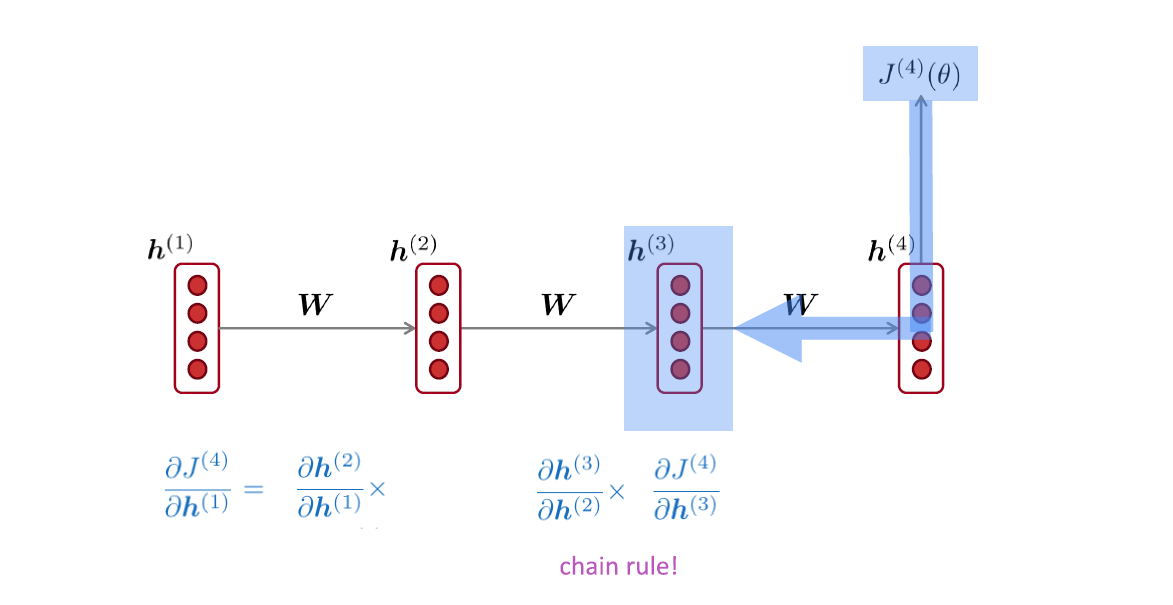


##### LSTM



LSTM networks were specifically designed to address this issue. They introduce a more sophisticated architecture with gates (input, forget, and output gates) that control the flow of information over time. These gates help the model decide what to remember, what to forget, and what to output at each step. As a result, LSTMs are much better at capturing long-range dependencies in sequences — which makes them a strong fit for our rating prediction task based on text reviews.

In the next section, we detail the LSTM model architecture used in our project and explain how we implemented it using Keras.


In [21]:
# Parameters
max_vocab = 50000
max_seq_len = 256  # max sequence length for padding/truncating
embedding_dim = 256
n_classes = 5  # num
# Create the TextVectorization layer
vectorize_layer = layers.TextVectorization(
    max_tokens=max_vocab,
    output_mode='int',
    output_sequence_length=max_seq_len,
    standardize='lower_and_strip_punctuation'
)
vectorize_layer.adapt(X_train['review'])
model = tf.keras.Sequential([
    layers.Input(shape=(1,), dtype=tf.string),  # Raw review text input
    vectorize_layer,                            # Text vectorization (int sequence)
    layers.Embedding(input_dim=50000, output_dim=256, mask_zero=True),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.GlobalMaxPooling1D(),
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(1, activation='linear')      # Output real-valued prediction
])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization (TextVec  (None, 256)              0         
 torization)                                                     
                                                                 
 embedding (Embedding)       (None, 256, 256)          12800000  
                                                                 
 bidirectional (Bidirectiona  (None, 256, 128)         164352    
 l)                                                              
                                                                 
 bidirectional_1 (Bidirectio  (None, 256, 128)         98816     
 nal)                                                            
                                                                 
 global_max_pooling1d (Globa  (None, 128)              0         
 lMaxPooling1D)                                         

Below is a breakdown of the model components and their rationale:

  **Text Vectorization**

We began by applying a `TextVectorization` layer, which transforms raw review text into integer sequences. This layer was configured with a vocabulary size of 50,000 (`max_tokens=50000`) and a fixed output sequence length of 256 tokens. It uses simple standardization (lowercasing and punctuation removal) to preprocess the text. The purpose of this layer is to convert unstructured textual input into a structured format that can be fed into neural network layers.
  **Embedding Layer**

The integer-encoded tokens are passed through an `Embedding` layer of shape `(50000, 256)`, where:

* `50000` is the size of the vocabulary (each unique word gets an embedding).
* `256` is the dimension of each word vector.

This layer learns dense vector representations for each word during training. We also set `mask_zero=True`, which ensures that padding tokens (represented by 0) are ignored by subsequent layers, preserving the integrity of sequence modeling.

 **Bidirectional LSTM Layers**

Since meaning in a sentence can depend on both previous and subsequent words, we used **Bidirectional LSTM** layers. These layers read the sequence in both forward and backward directions, capturing more context from both sides.

We stacked **two bidirectional LSTM layers**, each with 64 units and `return_sequences=True`, allowing the second LSTM to receive the full sequence of hidden states from the first. This stacking enables the model to capture deeper temporal features.
The following image represent a one bidirectional layer.


<center>
  <img src="https://i.imgur.com/N5LRW68.png" width="500"/>
</center>


 **Global Max Pooling**

To condense the sequence of hidden states into a single fixed-size vector, we used a `GlobalMaxPooling1D` layer. This layer extracts the maximum value for each feature across the time dimension, effectively summarizing the most important signal across the sequence. This representation serves as the review encoding.


 **Fully Connected Layers**

The pooled vector is then passed through:

* A `Dense` layer with 128 units and ReLU activation
* A `Dropout` layer with rate 0.5 (to prevent overfitting)
* A second `Dense` layer with 64 units and ReLU activation

These layers refine the representation and prepare it for prediction.

 **Output Layer**

Finally, the model outputs a single value through a `Dense` layer with `activation='linear'`, appropriate for our **regression task** (predicting review scores). The model was compiled using the **Mean Absolute Error (MAE)** loss, consistent with the evaluation metric used. wE Choose 



##### Training and Evaluating



Since the project’s target metric is Mean Absolute Error (MAE)—as used in the leaderboard evaluation—we approached the problem as a regression task rather than a classification one. While the labels represent discrete values from 1 to 5, they are ordinal in nature, and our goal is to minimize the average absolute difference between predictions and actual ratings.

This makes regression a more suitable framework than classification, as it allows the model to make continuous predictions and optimize directly for MAE during training.

In [22]:
model.compile(
    optimizer='adam',
    loss='mae',       # Directly minimizes Mean Absolute Error
    metrics=['mae']
)

To prevent overfitting and ensure optimal generalization, we applied early stopping, which monitors the validation loss and halts training when performance stops improving. Additionally, we used a model checkpoint to save the best-performing model during training based on the lowest validation MAE.

In [23]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',    # metric to monitor (validation loss here)
    patience=3,            # number of epochs to wait for improvement
    restore_best_weights=True  # after stopping, load best model weights
)

filepath = "LSTM/metwork_epoch_Final={epoch:02d}-val_loss={val_loss:.2f}"
checkpoint = callbacks.ModelCheckpoint(filepath=filepath, save_best_only=True, monitor='val_loss',mode='min')

In [24]:
# Train the model
y_train_float = y_train.astype('float32')
X_train_reviews = X_train['review'].values

history= model.fit(X_train_reviews, y_train_float, batch_size=32, epochs=5, validation_split=0.2,callbacks=[early_stop,checkpoint])
# Load the saved model
# model = tf.keras.models.load_model('LSTM/metwork_epoch_final=05-val_loss=0.51')

# Evaluate the model on the test set
y_test_float = y_test.astype('float32')
X_test_reviews = X_test['review'].values  
test_loss, test_mae = model.evaluate(X_test_reviews, y_test_float, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test MAE: {test_mae:.4f}")

Epoch 1/5
6762/6762 [==============================] - ETA: 0s - loss: 0.7327 - mae: 0.7327

INFO:tensorflow:Assets written to: LSTM\metwork_epoch_Final=01-val_loss=0.59\assets


INFO:tensorflow:Assets written to: LSTM\metwork_epoch_Final=01-val_loss=0.59\assets


6762/6762 [==============================] - 1011s 147ms/step - loss: 0.7327 - mae: 0.7327 - val_loss: 0.5884 - val_mae: 0.5884
Epoch 2/5
6762/6762 [==============================] - ETA: 0s - loss: 0.5497 - mae: 0.5497

INFO:tensorflow:Assets written to: LSTM\metwork_epoch_Final=02-val_loss=0.55\assets


...

INFO:tensorflow:Assets written to: LSTM\metwork_epoch_Final=04-val_loss=0.52\assets


6762/6762 [==============================] - 1098s 162ms/step - loss: 0.4193 - mae: 0.4193 - val_loss: 0.5246 - val_mae: 0.5246
Epoch 5/5
6762/6762 [==============================] - ETA: 0s - loss: 0.3766 - mae: 0.3766

INFO:tensorflow:Assets written to: LSTM\metwork_epoch_Final=05-val_loss=0.52\assets


INFO:tensorflow:Assets written to: LSTM\metwork_epoch_Final=05-val_loss=0.52\assets


6762/6762 [==============================] - 1074s 159ms/step - loss: 0.3766 - mae: 0.3766 - val_loss: 0.5178 - val_mae: 0.5178
2113/2113 - 104s - loss: 0.5171 - mae: 0.5171 - 104s/epoch - 49ms/step
Test Loss: 0.5171, Test MAE: 0.5171


In [25]:
# saving the history 
#joblib.dump(history.history, 'LSTM/history.joblib')

# Load the saved history
load_history = joblib.load('LSTM/history.joblib')

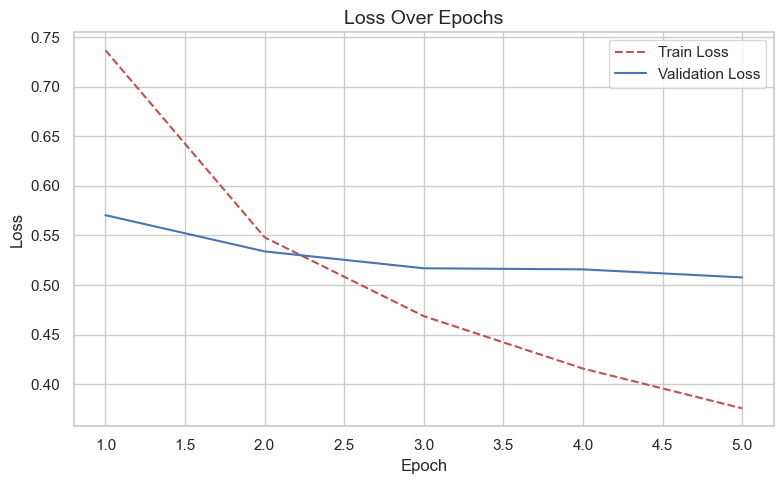

In [26]:
epochs = range(1, len(load_history['loss']) + 1)

plt.figure(figsize=(8, 5))  # Optional: make it larger

plt.plot(epochs,load_history['loss'], 'r--', label='Train Loss')       # Red dashed line
plt.plot(epochs,load_history['val_loss'], 'b-', label='Validation Loss')  # Blue solid line

plt.title('Loss Over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)  # Optional: adds gridlines
plt.tight_layout()
plt.show()


The training loss decreased rapidly, indicating that the model was able to quickly fit the training data. The validation loss also dropped significantly during the first two epochs, showing early generalization capability. After this initial phase, the rate of decrease in validation loss slowed down

Evaluating the LSTM on 30% of the unseen test set yielded a MAE of 0.50, showing a clear improvement over the logistic regression baseline. This highlights the value of sequential models in capturing linguistic patterns and opens the door for further exploration, such as integrating pre-trained word embeddings to enhance performance.

#### LSTM with pretrained Embedding 

Because the accuracy highly depends on the word representation (the word embeddings), we improved the previous model by changing the input. In contrast to our earlier LSTM model where the embedding matrix was randomly initialized and trained from scratch, we now use pre-trained embeddings that are fine-tuned during training (by setting `trainable=True` in the embeding layer). This allows the model to leverage rich semantic knowledge from large corpora while still adapting the embeddings to the specific characteristics of our dataset.

**FastText** is a static embedding algorithm that represents words as bags of character n-grams. This allows it to capture subword information, making it particularly effective for morphologically rich languages, rare words, and out-of-vocabulary (OOV) words. FastText generates word embeddings by training on large text corpus using a skip-gram or continuous bag-of-words (CBOW) model, optimized for speed and performance. It is widely used for tasks like text classification, sentiment analysis, and language modeling due to its ability to produce high-quality embeddings and handle large datasets efficiently.

Another very effective static embedding is **GloVe** (Global Vectors for Word Representation). It is an unsupervised learning algorithm developed by Stanford researchers for generating word embeddings. Unlike FastText, which focuses on subword information, GloVe leverages global word co-occurrence statistics from a corpus to create dense vector representations. It constructs a word co-occurrence matrix and factorizes it to produce embeddings that capture **semantic relationships** (e.g., "king" - "man" + "woman" ≈ "queen")

In this case we decided to combine these complemetary types of embeddings because FastText can generate embeddings for OOV words by combining n-gram vectors, while GloVe cannot. So by averaging, we ensure that OOV words still have meaningful representations (from FastText) while benefiting from GloVe’s semantic richness for known words.

Furthermore, for scalability and execuion time optimization we directly downloaded pre-trained GloVe and FastText of 300 dimensions embeddings (crawl-300d-2M.vec and glove.6B.300d.txt)

In [27]:
# Load embeddings (GloVe, FastText, or combined)
def load_embeddings(vocabulary, embedding_type='glove', glove_file_path=None, fasttext_file_path=None, embedding_dim=300):
    embeddings_index = {}
    
    if embedding_type in ['glove', 'combined'] and glove_file_path:
        with open(glove_file_path, encoding='utf-8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                coefs = np.asarray(values[1:], dtype='float32')
                embeddings_index[f'glove_{word}'] = coefs
    
    if embedding_type in ['fasttext', 'combined'] and fasttext_file_path:
        with open(fasttext_file_path, encoding='utf-8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                coefs = np.asarray(values[1:], dtype='float32')
                embeddings_index[f'fasttext_{word}'] = coefs

    word_index = {word: idx for idx, word in enumerate(vocabulary)}
    embedding_matrix = np.zeros((len(vocabulary), embedding_dim))
    
    for word, i in word_index.items():
        if embedding_type == 'glove':
            embedding_vector = embeddings_index.get(f'glove_{word}')
        elif embedding_type == 'fasttext':
            embedding_vector = embeddings_index.get(f'fasttext_{word}')
        else:  # combined
            glove_vec = embeddings_index.get(f'glove_{word}')
            fasttext_vec = embeddings_index.get(f'fasttext_{word}')
            if glove_vec is not None and fasttext_vec is not None:
                embedding_vector = (glove_vec + fasttext_vec) / 2
            else:
                embedding_vector = glove_vec if glove_vec is not None else fasttext_vec
        
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
    
    return embedding_matrix

In [28]:
# Parameters
max_vocab = 50000
max_seq_len = 256
embedding_dim = 300
n_classes = 5


# Create and adapt TextVectorization layer
vectorize_layer = layers.TextVectorization(
    max_tokens=max_vocab,
    output_mode='int',
    output_sequence_length=max_seq_len,
    standardize='lower_and_strip_punctuation'
)
vectorize_layer.adapt(X_train['review'])  

# File paths (update as needed)
glove_file_path = 'glove.6B.300d.txt'
fasttext_file_path = 'crawl-300d-2M.vec'

# Choose embedding type: 'glove', 'fasttext', or 'combined'
embedding_type = 'combined'  # Change to 'glove' or 'combined' as needed
embedding_matrix = load_embeddings(
    vocabulary=vectorize_layer.get_vocabulary(),
    embedding_type=embedding_type,
    glove_file_path=glove_file_path,
    fasttext_file_path=fasttext_file_path,
    embedding_dim=embedding_dim
)

# Build the model
model = tf.keras.Sequential([
    layers.Input(shape=(1,), dtype=tf.string),
    vectorize_layer,
    layers.Embedding(
        input_dim=len(vectorize_layer.get_vocabulary()),
        output_dim=embedding_dim,
        embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
        trainable=True, 
        mask_zero=True
    ),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.GlobalMaxPooling1D(),
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(1, activation='linear', dtype='float32')  
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization_1 (TextV  (None, 256)              0         
 ectorization)                                                   
                                                                 
 embedding_1 (Embedding)     (None, 256, 300)          15000000  
                                                                 
 bidirectional_2 (Bidirectio  (None, 256, 128)         186880    
 nal)                                                            
                                                                 
 bidirectional_3 (Bidirectio  (None, 256, 128)         98816     
 nal)                                                            
                                                                 
 global_max_pooling1d_1 (Glo  (None, 128)              0         
 balMaxPooling1D)                                     

In [29]:
# Compile the model
model.compile(optimizer='adam', loss='mae', metrics=['mae'])

In [32]:
# Train
# Create datasets
y_train_flatten = y_train.astype('float32').values.reshape(-1, 1).flatten()
train_dataset = tf.data.Dataset.from_tensor_slices((X_train['review'].values, y_train_flatten))
train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

y_test_flatten = y_test.astype('float32').values.reshape(-1, 1).flatten()
val_dataset = tf.data.Dataset.from_tensor_slices((X_test['review'].values, y_test_flatten))
val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

# Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=f'LSTM_new/final_{embedding_type}_model_epoch={{epoch:02d}}-val_loss={{val_loss:.2f}}',
    save_best_only=True,
    monitor='val_loss',
    mode='min'
)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)


In [33]:
# Train
model.fit(
    train_dataset,
    epochs=4,
    validation_data=val_dataset,
    callbacks=[early_stop, checkpoint, lr_scheduler],initial_epoch=1
)

Epoch 2/4
8452/8452 [==============================] - ETA: 0s - loss: 0.5075 - mae: 0.5075

INFO:tensorflow:Assets written to: LSTM_new\final_combined_model_epoch=02-val_loss=0.51\assets


INFO:tensorflow:Assets written to: LSTM_new\final_combined_model_epoch=02-val_loss=0.51\assets


8452/8452 [==============================] - 2024s 239ms/step - loss: 0.5075 - mae: 0.5075 - val_loss: 0.5138 - val_mae: 0.5138 - lr: 0.0010
Epoch 3/4
8452/8452 [==============================] - ETA: 0s - loss: 0.4245 - mae: 0.4245

INFO:tensorflow:Assets written to: LSTM_new\final_combined_model_epoch=03-val_loss=0.51\assets


INFO:tensorflow:Assets written to: LSTM_new\final_combined_model_epoch=03-val_loss=0.51\assets


8452/8452 [==============================] - 1779s 210ms/step - loss: 0.4245 - mae: 0.4245 - val_loss: 0.5117 - val_mae: 0.5117 - lr: 0.0010
Epoch 4/4
8452/8452 [==============================] - ETA: 0s - loss: 0.3720 - mae: 0.3720

INFO:tensorflow:Assets written to: LSTM_new\final_combined_model_epoch=04-val_loss=0.50\assets


INFO:tensorflow:Assets written to: LSTM_new\final_combined_model_epoch=04-val_loss=0.50\assets


8452/8452 [==============================] - 2560s 303ms/step - loss: 0.3720 - mae: 0.3720 - val_loss: 0.5029 - val_mae: 0.5029 - lr: 0.0010


Evaluating our model on the held-out 30% test set yielded a Mean Absolute Error (MAE) of 0.46. Compared to the baseline LSTM model trained without pre-trained embeddings—which achieved an MAE of 0.50—this demonstrates that incorporating pre-trained word embeddings (FastText and GloVe) improved the model’s ability to generalize and capture richer semantic meaning in the text.

### 2.3 DistilBert

Transformers are a neural network architecture designed for processing sequential data, i.e., natural language. Transformers were first proposed in the paper "Attention is All You Need" (Vaswani et al., 2017) and have ever since formed the foundation of many state-of-the-art NLP models, e.g., BERT, GPT.

Unlike traditional recurrent models (like RNNs or LSTMs), transformers process the entire input sequence parallel, not one at a time. That also makes them quicker and better at modeling long-range dependencies in text.

The key innovation of transformers is the self-attention mechanism, allowing the model to take into account the relative significance of different words in a sentence regardless of their position. 

In our project, we use DistilBERT, a distilled variant of BERT that still uses the transformer architecture. It uses the review text as input in the form of a sequence of tokens, applies layers of self-attention and feed-forward networks, and generates context-dependent representations of the input. These representations are used to predict the rating of the review.

Since transformer models like DistilBERT are designed to work directly with natural language, we intentionally avoid aggressive text cleaning. Our preprocessing function only removes URLs, normalizes whitespace, and trims leading/trailing spaces. We also handle missing values by concatenating the summary and text fields, replacing any missing values with empty strings. 

Finally, we removed duplicate reviews based on the combined text. More advanced steps like lowercasing, stemming, or stopword removal are not applied, as they can actually degrade the performance of models like DistilBERT that have been pretrained on unaltered language data

We set the seed for all processors (GPU and CPU) to ensure reproducibility of the results.

In [34]:
# Set seeds for reproducibility
SEED = 42

# Python built-in randomness
random.seed(SEED)

# NumPy randomness
np.random.seed(SEED)

# PyTorch CPU randomness
torch.manual_seed(SEED)

# If using CUDA (NVIDIA GPU)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# If using Apple Silicon / MPS (safe to include)
if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    torch.manual_seed(SEED)  # MPS shares CPU seeds

# Force PyTorch to use deterministic algorithms (where possible)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


We selected DistilBERT as our base model due to its efficient trade-off between computational cost and representational power. As a distilled version of BERT, it retains most of the language understanding capabilities of the original model while offering significantly reduced model size and faster inference.

To further optimize for our task, we used the uncased variant (distilbert-base-uncased), which normalizes all input text to lowercase during tokenization. Using an uncased model reduces sensitivity to noisy casing and improves robustness, as users tend to be less thorough in their use of capitalization.

In [35]:
# Set Tokenizer
PRE_TRAINED_MODEL_NAME = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)

c:\Users\EASYPC\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



We create a specific dataset class using Pytorch (for GPU optimization on Mac) that prepares our book review data for use with a DistilBERT model. It takes in a list of texts, an optional list of targets (the review ratings), a tokenizer (we pre-set it to DistilBertTokenizer), and a maximum sequence length. When the dataset is accessed through indexing, it tokenizes the text using the provided tokenizer, ensuring that all sequences are padded or truncated to the specified maximum length. 

It also creates an attention mask to indicate which tokens are real and which are padding. These inputs are returned as PyTorch tensors. If the dataset was initialized with target values, it also includes the corresponding rating as a float tensor. This setup allows us to efficiently feed tokenized and properly formatted inputs into our model for both training and inference.

In [36]:
# Custom Dataset class to prepare review text and (optionally) target ratings for DistilBERT
class ReviewDataset(Dataset):
    def __init__(self, texts, targets, tokenizer, max_len=128):
        self.texts = texts                    
        self.targets = targets                
        self.tokenizer = tokenizer            # DistilBertTokenizer tokenizer 
        self.max_len = max_len                # Maximum token sequence length

    def __len__(self):
        # Return the number of samples in the dataset
        return len(self.texts)

    def __getitem__(self, idx):
        # Retrieve the text at index idx
        text = self.texts[idx]

        # Tokenize the text using the provided tokenizer
        inputs = self.tokenizer.encode_plus(
            text,
            None,  # No second sentence (not using sentence-pair input)
            add_special_tokens=True,           # Add [CLS] and [SEP] tokens
            max_length=self.max_len,           # Truncate/pad to this length
            padding='max_length',              # Pad sequences shorter than max_len
            truncation=True,                   # Truncate sequences longer than max_len
            return_attention_mask=True,        # Return attention mask (1 for real tokens, 0 for padding)
            return_tensors='pt'                # Return PyTorch tensors instead of lists
        )

        # Build the sample dictionary
        item = {
            'input_ids': inputs['input_ids'].flatten(),         # Flatten from [1, max_len] to [max_len]
            'attention_mask': inputs['attention_mask'].flatten() # Flatten the same way
        }

        # If targets (ratings) are provided, include them
        if self.targets is not None:
            item['targets'] = torch.tensor(self.targets[idx], dtype=torch.float)

        return item  # Return a dictionary containing the input tensors and (optionally) the target


The DistilBERTRegressor is a simple regression model built on top of a pretrained DistilBERT transformer. It takes tokenized text input and passes it through DistilBERT to obtain contextual embeddings. We extract the embedding of the first token (typically used as a summary of the sequence), apply dropout for regularization, and feed it into a linear layer that outputs a single scalar value. This design allows the model to predict a continuous rating score based on the input review text, that then will be rounded to it's closest rating integer.

In [37]:
# Define a regression model using a pretrained DistilBERT backbone
class DistilBERTRegressor(nn.Module):
    def __init__(self):
        super().__init__()

        # Load the pretrained DistilBERT model (outputs hidden states for each token)
        self.bert = DistilBertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)

        # Dropout layer with 50% dropout rate to prevent overfitting
        self.dropout = nn.Dropout(0.5)

        # Linear output layer: maps the hidden state to a single scalar output (for regression)
        self.out = nn.Linear(self.bert.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        # Pass inputs through DistilBERT and get the last hidden state for all tokens
        x = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state

        # Select the hidden state corresponding to the [CLS] token (first token in sequence)
        x = x[:, 0, :]

        # Apply dropout for regularization
        x = self.dropout(x)

        # Pass through the output layer and squeeze to get shape [batch_size]
        return self.out(x).squeeze(1)

In [38]:
train_texts, val_texts, train_targets, val_targets = train_test_split(
    df["review"].tolist(),
    df["rating"].astype(np.float32).values,
    test_size=0.2,
    random_state=SEED
)

In [39]:
train_ds = ReviewDataset(train_texts, train_targets, tokenizer)
val_ds = ReviewDataset(val_texts, val_targets, tokenizer)

generator = torch.Generator().manual_seed(SEED) # for reproducibility
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, generator=generator)
val_loader = DataLoader(val_ds, batch_size=32)

We create a train_and_validate function to see how the model performs on a training and validation data set.

In [40]:
def train_and_validate(model, train_loader, val_loader, optimizer, criterion, device, epochs=10, patience=3, min_delta=0.0, save_path="best_model_val.pth"):
    # Lists to store average loss (MAE) per epoch
    train_losses = []
    val_losses = []

    # Track the best validation loss for early stopping
    best_val_loss = float("inf")
    patience_counter = 0

    # Loop through each epoch
    for epoch in range(epochs):
        model.train()  # Set model to training mode
        train_loss = 0.0  # Track total training loss for this epoch

        # Training loop
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} [train]"):
            # Move inputs and targets to the appropriate device (CPU/GPU)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            targets = batch['targets'].to(device)

            optimizer.zero_grad()  # Clear gradients
            outputs = model(input_ids, attention_mask)  # Forward pass
            loss = criterion(outputs, targets)  # Compute loss (e.g., MAE)
            loss.backward()  # Backward pass
            optimizer.step()  # Update model parameters
            train_loss += loss.item()  # Accumulate loss

        model.eval()  # Set model to evaluation mode
        val_loss = 0.0  # Track total validation loss

        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1} [val]"):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                targets = batch['targets'].to(device)

                outputs = model(input_ids, attention_mask)  # Forward pass
                loss = criterion(outputs, targets)  # Compute validation loss
                val_loss += loss.item()  # Accumulate loss

        # Compute average MAE for train and validation
        train_mae = train_loss / len(train_loader)
        val_mae = val_loss / len(val_loader)

        # Store losses for plotting later
        train_losses.append(train_mae)
        val_losses.append(val_mae)

        print(f"Epoch {epoch+1} -- Train MAE: {train_mae:.4f} | Val MAE: {val_mae:.4f}")

        # Save model checkpoint if validation loss improved
        if val_mae + min_delta < best_val_loss:
            print(f"Saving improved model at epoch {epoch+1}")
            best_val_loss = val_mae
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            # If no improvement, increase patience counter
            patience_counter += 1
            if patience_counter >= patience:
                # Stop early if validation doesn't improve for 'patience' epochs
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    return train_losses, val_losses  # Return history of losses for plotting


We use MAE as a criterion, to ensure comparable results with other models.

In [ ]:
model = DistilBERTRegressor().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.L1Loss()

train_losses, val_losses = train_and_validate(model, train_loader, val_loader, optimizer, criterion, device)


Epoch 1 [val]: 100%|██████████| 2113/2113 [04:35<00:00,  7.67it/s]


Epoch 1 -- Train MAE: 0.6007 | Val MAE: 0.5037
Saving improved model at epoch 1


Epoch 2 [val]: 100%|██████████| 2113/2113 [04:29<00:00,  7.85it/s]


Epoch 2 -- Train MAE: 0.5083 | Val MAE: 0.5126


Epoch 3 [val]: 100%|██████████| 2113/2113 [04:30<00:00,  7.80it/s]


...

Epoch 5 -- Train MAE: 0.4028 | Val MAE: 0.4979


Epoch 6 [val]: 100%|██████████| 2113/2113 [04:35<00:00,  7.68it/s]


Epoch 6 -- Train MAE: 0.3807 | Val MAE: 0.4946


Epoch 7 [val]: 100%|██████████| 2113/2113 [04:28<00:00,  7.87it/s]

Epoch 7 -- Train MAE: 0.3626 | Val MAE: 0.5001
Early stopping triggered at epoch 7


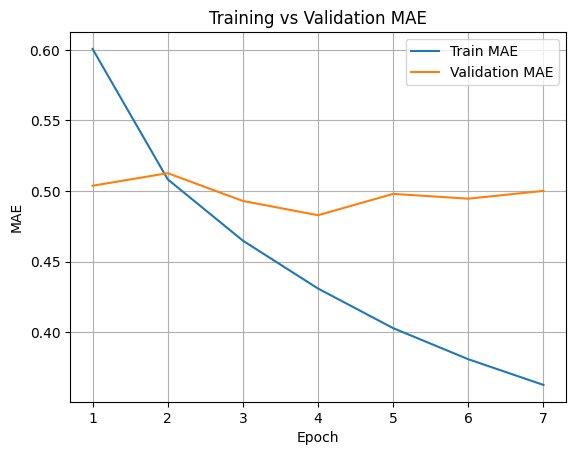

In [ ]:

plt.plot(train_losses, label='Train MAE')
plt.plot(val_losses, label='Validation MAE')
plt.xlabel('Epoch')
plt.xticks(range(len(train_losses)), range(1, len(train_losses) + 1))
plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.grid(True)
plt.show()


From the above plot, we see that the training MAE is fastly decreasing at the second epoch, then it keeps on decreasing slower afterwards. Even though the validation MAE is performs better at the first epoch, it does not increase much throughout the following epochs. The lowest validation MAE appeared at the 4th epoc. We will set this limit to the model that we train on the complete training data set. 

In [ ]:
# Use all data
full_train_ds = ReviewDataset(df["review"].tolist(), df["review"].astype(np.float32).values, tokenizer)
full_train_loader = DataLoader(full_train_ds, batch_size=32, shuffle=True)

# New model
model = DistilBERTRegressor().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.L1Loss()

def train_full(model, train_loader, optimizer, criterion, device, epochs=10, min_delta=0.001, save_path="best_model_full.pth"):
    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} [full training]"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            targets = batch['targets'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        epoch_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}: Full Train MAE: {epoch_loss:.4f}")

        if epoch_loss + min_delta < best_loss:
            print(f"Saving model at epoch {epoch+1}")
            best_loss = epoch_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)


In [ ]:
train_full(
    model, full_train_loader,
    optimizer, criterion, device,
    epochs=4, min_delta=0.001
)

Epoch 1 [full training]: 100%|██████████| 10565/10565 [59:14<00:00,  2.97it/s] 


Epoch 1: Full Train MAE: 0.5904
Saving model at epoch 1


Epoch 2 [full training]: 100%|██████████| 10565/10565 [59:12<00:00,  2.97it/s]


Epoch 2: Full Train MAE: 0.5041
Saving model at epoch 2


Epoch 3 [full training]: 100%|██████████| 10565/10565 [58:59<00:00,  2.99it/s]


Epoch 3: Full Train MAE: 0.4657
Saving model at epoch 3


Epoch 4 [full training]: 100%|██████████| 10565/10565 [58:03<00:00,  3.03it/s]


Epoch 4: Full Train MAE: 0.4367
Saving model at epoch 4


The training losses are comparable with what has been observed during the training on 80% of teh data set. 

## 3. Submission

In [ ]:
test=pd.read_csv('ATML2025_book_reviews_test_covariates.csv')
test.head()

In [ ]:
test["review"] = (test["summary"].fillna("") + " " + test["text"].fillna("")).apply(preprocess)


In [ ]:
model.eval()
test_ds = ReviewDataset(test["review"].tolist(), None, tokenizer)
test_loader = DataLoader(test_ds, batch_size=32)

test_preds = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids, attention_mask)
        preds = torch.clamp(torch.round(outputs), 1, 5).int()
        test_preds.extend(preds.cpu().numpy())


Predicting: 100%|██████████| 4782/4782 [10:00<00:00,  7.96it/s]


In [ ]:

submission = pd.DataFrame({
    "id": test["id"],
    "rating": test_preds
})
submission.to_csv("submission_distil_bert_final.csv", index=False)


The final model got a MAE of 0.4341 on the Kaggle leaderboard, which was better than all the previous models, including LSTM models with or without pre-trained embeddings. This shows that using a pre-trained DistilBERT model helped capture the meaning in the reviews better.

That said, transformer models like DistilBERT are much heavier in terms of computation. They take more time to train and use more memory. So even if the performance is better, it comes at a higher computational cost.

###  Declaration of Generative AI Tool Usage

ChatGPT (OpenAI, GPT-4) was used as a generative AI tool to support the development of this assignment.

ChatGPT was asked for assistance in order to draft functions for model testing and potential improvement.

All implementation, fine-tuning, and interpretation were conducted by our team. We wrote the final code, results analysis, and structured the notebook.